In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from os.path import join
%matplotlib inline
import seaborn as sns
from PSPupil import dataset as dt
from datetime import datetime

from sklearn.metrics import roc_curve, roc_auc_score

from scipy.stats import ttest_ind, linregress, f_oneway#, tukey_hsd
from decim.adjuvant import slurm_submit as slu
import itertools



def smaller_than(value):
    logs=np.append(np.logspace(-15, 1, 17), .05)
    sorteds=np.sort(np.append(logs, value))
    index=np.where(sorteds==value)[0]
    return sorteds[index+1][0]

def p_annot(p_value):
    if p_value < 0.01:
        text = 'p <{0}'.format(smaller_than(p_value))
    else:
        text = 'p= %.2f' % p_value
    
    if p_value<0.05:
        bold = 'bold'
    else: 
        bold = 'normal'
    return text, bold
        

def func_powerlaw(x, m, c, c0):
    return c0 + x**m * c

def permutation_cluster_test(x1, x2):
    f, clusters, pvalues, h0=mne.stats.permutation_cluster_test([x1,x2],
                                                                     threshold=dict(start=0, step=0.2))
    return pvalues

def rgb_to_hex(r, g, b):
    return '#{:02x}{:02x}{:02x}'.format(r, g, b)


def show_p_statistic(yticks):
    ylim = yticks[1] + 2/5 * (yticks[1] - yticks[0])
    first=4/5 * (ylim - yticks[1]) + yticks[1]
    third=2/5 * (ylim - yticks[1]) + yticks[1]
    offset=(first-yticks[0])/25
    return ylim, first, third, offset


edition = '/Volumes/psp_data/PSP/Pupil_Preprocessed_2024-06-17/'
slu.mkdir_p(join(edition, 'PowerFrequencies'))
slu.mkdir_p(join(edition, 'Figures'))

out = join(edition, 'Figures', 'Figure_1_{}'.format(datetime.now().strftime("%Y-%m-%d")))
slu.mkdir_p(out)



In [90]:
def subplot(j, ylabel, yticks, data, title=None):
    ylim, first, third, offset = show_p_statistic(yticks)
    p=data[0]
    i=data[1]
    c=data[2]


    ax[j].scatter(np.zeros(p.shape), p, color=baseline_color, label='PSP', s=scatter_marker, alpha = scatter_alpha)
    ax[j].scatter(np.ones(i.shape), i, color=ips_color, label = 'PD', s=scatter_marker, alpha = scatter_alpha)
    ax[j].scatter(np.ones(c.shape)*2, c, color=control_color, label = 'CTRL', s=scatter_marker, alpha = scatter_alpha)


    ax[j].boxplot(p, positions=[0],widths=.5, boxprops = dict(linewidth=line_width_b), whiskerprops = dict(linewidth=line_width_b), capprops = dict(linewidth=line_width_b),
               medianprops = dict(linestyle='-', linewidth=line_width_b, color='black'), showfliers=False, whis=(0, 100))

    ax[j].boxplot(i, positions=[1], widths=.5, boxprops = dict(linewidth=line_width_b), whiskerprops = dict(linewidth=line_width_b), capprops = dict(linewidth=line_width_b),
               medianprops = dict(linestyle='-', linewidth=line_width_b, color='black'), showfliers=False, whis=(0, 100))

    ax[j].boxplot(c, positions=[2], widths=.5, boxprops = dict(linewidth=line_width_b), whiskerprops = dict(linewidth=line_width_b), capprops = dict(linewidth=line_width_b),
               medianprops = dict(linestyle='-', linewidth=line_width_b, color='black'), showfliers=False, whis=(0, 100))

    ax[j].set(xlabel='',
          xticks=[0,1, 2],
          xticklabels=['PSP', 'PD',
                      'Controls'],
          ylabel=ylabel,
           ylim=[yticks[0], ylim],
          yticks=yticks)

    ax[j].vlines(0, ymin=first-offset, ymax=first+offset, lw=line_width_p)
    ax[j].vlines(2, ymin=first-offset, ymax=first+offset, lw=line_width_p)
    ax[j].plot((0, 2), (first, first), color='black', lw=line_width_p)
    ax[j].annotate(p_annot(ttest_ind(p,c)[1])[0], weight = p_annot(ttest_ind(p,c)[1])[1], xy=(1,first), fontsize=psize, ha='center', va='center', bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=1))

    ax[j].vlines(0, ymin=third-offset, ymax=third+offset, lw=line_width_p)
    ax[j].vlines(1, ymin=third-offset, ymax=third+offset, lw=line_width_p)
    ax[j].plot((0, 1), (third, third), color='black', lw=line_width_p)
    ax[j].annotate(p_annot(ttest_ind(p,i)[1])[0], weight = p_annot(ttest_ind(p,i)[1])[1], xy=(.5,third), fontsize=psize, ha='center', va='center', bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=1))

    ax[j].vlines(1, ymin=third-offset, ymax=third+offset, lw=line_width_p)
    ax[j].vlines(2, ymin=third-offset, ymax=third+offset, lw=line_width_p)
    ax[j].plot((1, 2), (third, third), color='black', lw=line_width_p)
    ax[j].annotate(p_annot(ttest_ind(c,i)[1])[0], weight = p_annot(ttest_ind(c,i)[1])[1], xy=(1.5,third), fontsize=psize, ha='center', va='center', bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=1))
    if title is not None:
        ax[j].set_title(title)
    
def subplot_2(j, ylabel, yticks, data, xticklabels=['BL', 'FU'], print_p=False, title=None):
    bl = data[0]
    fl = data [1]
    ylim, first, third, offset = show_p_statistic(yticks)
    ax[j].scatter(np.zeros(bl.shape), bl, color=baseline_color, label='PSP', s=scatter_marker, alpha = scatter_alpha)
    ax[j].scatter(np.ones(fl.shape), fl, color=follow_color, label = 'PD', s=scatter_marker, alpha = scatter_alpha)


    ax[j].boxplot(bl, positions=[0],widths=.5, boxprops = dict(linewidth=line_width_b), whiskerprops = dict(linewidth=line_width_b), capprops = dict(linewidth=line_width_b),
               medianprops = dict(linestyle='-', linewidth=line_width_b, color='black'), showfliers=False, whis=(0, 100))

    ax[j].boxplot(fl, positions=[1], widths=.5, boxprops = dict(linewidth=line_width_b), whiskerprops = dict(linewidth=line_width_b), capprops = dict(linewidth=line_width_b),
               medianprops = dict(linestyle='-', linewidth=line_width_b, color='black'), showfliers=False, whis=(0, 100))

    ax[j].set(xlabel='',
          xticks=[0,1, 2],
          xticklabels=xticklabels,
          ylabel=ylabel,
           ylim=[yticks[0], ylim],
          yticks=yticks)
    ax[j].vlines(0, ymin=third-offset, ymax=third+offset, lw=line_width_p)
    ax[j].vlines(1, ymin=third-offset, ymax=third+offset, lw=line_width_p)
    ax[j].plot((0, 1), (third, third), color='black', lw=line_width_p)
    ttest = ttest_ind(bl, fl)
    if print_p is True:
        print(ylabel, ttest)
    ax[j].annotate(p_annot(ttest[1])[0], weight = p_annot(ttest[1])[1], xy=(.5,third), fontsize=psize, ha='center', va='center', bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=1))
    if title is not None:
        ax[j].set_title(title)


## Figures for Manuscript V5
- after Feedback, before submission
- Preprocessing used: 'Pupil_Preprocessed_2024-06-17'
- i.e. fooof included, no z-scoring

- Differences: 
    - reran FOOOF on changed range 1/32 - 1 Hz (before 0.01-1Hz)
    

In [118]:
#Plotting parameters
palette = sns.color_palette("Paired")

'''
baseline_color = palette[4]
followup_color = palette[5]
ips_color = palette[0]
control_color = palette[2]
r = rgb_to_hex(196, 98, 74)
ips_color = rgb_to_hex(123, 118, 19)
control_color = rgb_to_hex(228, 193, 91)
baseline_color = '#F0746E'
follow_color = baseline_color
ips_color = '#7CCBA2'
control_color = '#FCDE9C'
'''



colorcycler=["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"]
linecycler=["-", "--", "-.", ":", "-", "--", "-."]


baseline_color = 'tab:red'
follow_color = baseline_color
ips_color = 'tab:purple'
control_color = 'tab:orange'

sns.set(style='ticks')
sns.set(style='ticks',font='HelveticaNeue', font_scale=1, rc={
    'axes.labelsize': 6,
    'axes.titlesize': 6,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'axes.linewidth': .5,
    'xtick.major.width': .5,
    'ytick.major.width': .5,
        'xtick.minor.width': .5,
    'ytick.minor.width': .5,
    'ytick.major.pad': 0,
    'ytick.minor.pad': 1.0,
    'xtick.major.pad': 1.0,
    'xtick.minor.pad': 1.0,
    'axes.labelpad': 0,
    "xtick.major.size":2,
    "xtick.minor.size":1,
    "ytick.major.size":2,
    "ytick.minor.size":1
})


psize=4
line_width_p = .4
scatter_marker = 16
scatter_alpha=.5

line_width_b = .5

lw_power1 = 1.5
lw_power = 1

In [119]:
5

5

## 1. Power Spectra ALl groups main (Fig 1A)

In [120]:
# data for plotting: 
popt = np.load(join(edition, 'Figures', 'data', 'popt.npy')) 
auc_x = np.load(join(edition, 'Figures', 'data', 'auc_x.npy')) 
pvals_psp_pd = np.load(join(edition, 'Figures', 'data', 'pvals_psp_pd.npy'))
pvals_psp_c = np.load(join(edition, 'Figures', 'data', 'pvals_psp_c.npy')) 
permut_x = np.load(join(edition, 'Figures', 'data', 'permut_x.npy')) 


psp_baseline_avg = pd.read_hdf(join(edition, 'Figures', 'data', 'psp_baseline_avg.hdf'), 
                           key = 'data') 
pd_fpower_avg = pd.read_hdf(join(edition, 'Figures', 'data', 'pd_fpower_avg.hdf'), 
                            key = 'data') 
ctrl_fpower_avg = pd.read_hdf(join(edition, 'Figures', 'data', 'ctrl_fpower_avg.hdf'), 
                              key = 'data') 

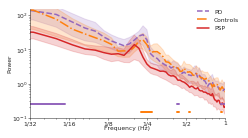

In [121]:
f, ax = plt.subplots(figsize=(3.5, 2))
f.suptitle('')
ci=95


stacked = pd_fpower_avg.drop(['session'], axis=1).unstack().reset_index()
plot = sns.lineplot(data= stacked, x='level_0', y=0, ci=ci, color=ips_color, lw=0, label=None, alpha=1, dashes=[(2,2)])
plt.plot(stacked.groupby('level_0').mean().index, stacked.groupby('level_0').mean().values, label='PD', linewidth=lw_power1, color = ips_color, linestyle=linecycler[1])


stacked = ctrl_fpower_avg.drop(['session'], axis=1).unstack().reset_index()
plot = sns.lineplot(data= stacked, x='level_0', y=0, ci=ci, color=control_color, lw=0, label=None, alpha=1, dashes=linecycler[2])
plt.plot(stacked.groupby('level_0').mean().index, stacked.groupby('level_0').mean().values, label='Controls', linewidth=lw_power1, color = control_color, linestyle=linecycler[2])


stacked = psp_baseline_avg.drop(['session'], axis=1).unstack().reset_index()
plot = sns.lineplot(data= stacked, x='level_0', y=0, ci=ci, color=baseline_color, lw=0, label=None, alpha=1, dashes=linecycler[0])
plt.plot(stacked.groupby('level_0').mean().index, stacked.groupby('level_0').mean().values, label='PSP', linewidth=lw_power1, color = baseline_color, linestyle=linecycler[0])


plot.set(xscale='log', yscale='log')
plot.set(xlim = (1/32, 1), ylim=(.1, 150))
ax.set(xlabel='Frequency (Hz)',
      ylabel='Power',
      xticks=[1/32,1/16, 1/8, 1/4, 1/2, 1],
      xticklabels=['1/32','1/16', '1/8', '1/4', '1/2', '1'])
sns.despine()



#plt cluster permutation test results
a=.15
cluster_distance = np.diff(permut_x).mean()/2
for i in permut_x[pvals_psp_c<0.05]:
    plt.plot([i-cluster_distance, i+cluster_distance], [a, a], color=control_color, lw=2)

a = .25
for i in permut_x[pvals_psp_pd<0.05]:
    plt.plot([i-cluster_distance, i+cluster_distance], [a, a], color=ips_color, lw=2)
    

#plt.scatter(permut_x[pvals_psp_pd<0.05],  np.repeat(.15, len(permut_x[pvals_psp_pd<0.05]), axis=None), color='black', marker='*')

#plt.scatter(permut_x[pvals_psp_c<0.05].values, .05, color='grey', marker='*')
#plt.scatter(permut_x[pvals_pd_cont<0.05].values, .05, color='lightgrey', marker='*')



ax.legend(bbox_to_anchor=(1.1, 1.05), frameon=False)

#f.tight_layout()
f.savefig(join(out, 'PowerSpectra_all_groups.png'), dpi=600)


## 1D
- changed new specparams run with changed range

In [123]:
## load data
CoV = pd.read_hdf(join(edition, 'PowerFrequencies', 'CoV.hdf'), key='data')
CoV.loc[:, 'CoV'] = CoV.loc[:, 'std'] / CoV.loc[:, 'mean'] *100
auc = pd.read_hdf(join(edition, 'PowerFrequencies', 'auc_bp_non_normalized.hdf'), key='data')
psp_baseline_auc = auc.loc[(auc.group == 'PSP')&(auc.session == 'Baseline')]
pd_auc = auc.loc[(auc.group == 'PD')&(auc.session == 'Baseline')]
ctrl_auc = auc.loc[(auc.group == 'Control')&(auc.session == 'Baseline')]
fooov = pd.read_hdf(join(edition, 'SPECPARAMS', 'Specparams_2025-09-09.hdf'), key= 'data')

### Exclude PD subject 12
CoV = CoV.set_index(['group', 'subject']).drop(('PD', '12')).reset_index()
fooov = fooov.set_index(['group', 'subject']).drop(('PD', '12')).reset_index()
pd_auc = pd_auc.set_index(['group', 'subject']).drop(('PD', '12')).reset_index()


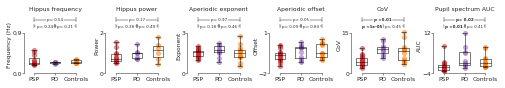

In [124]:
f, ax = plt.subplots(1, 6, figsize = (7, 1.2))

# 1. Frequency
df = fooov.loc[(fooov.session == 'Baseline')&(~fooov.peak1_CF.isnull())]
p = df.loc[df.group == 'PSP'].peak1_CF.values
i = df.loc[df.group == 'PD'].peak1_CF.values
c = df.loc[df.group == 'Control'].peak1_CF.values
subplot(j=0, yticks=[0, 0.9], ylabel = 'Frequency (Hz)', data = [p, i, c], title='Hippus frequency')

# 2. power
df = fooov.loc[(fooov.session == 'Baseline')&(~fooov.peak1_CF.isnull())]
p = df.loc[df.group == 'PSP'].peak1_PW.values
i = df.loc[df.group == 'PD'].peak1_PW.values
c = df.loc[df.group == 'Control'].peak1_PW.values
subplot(j=1, yticks=[0, 2], ylabel = 'Power', data = [p, i, c], title='Hippus power')

# 3. Exponent
df = fooov.loc[(fooov.session == 'Baseline')]
p = df.loc[df.group == 'PSP'].aperiodic_exp.values
i = df.loc[df.group == 'PD'].aperiodic_exp.values
c = df.loc[df.group == 'Control'].aperiodic_exp.values
subplot(j=2, yticks=[0, 3], ylabel = 'Exponent', data = [p, i, c], title='Aperiodic exponent')

# 3. Offset
df = fooov.loc[(fooov.session == 'Baseline')]
p = df.loc[df.group == 'PSP'].aperiodic_offset.values
i = df.loc[df.group == 'PD'].aperiodic_offset.values
c = df.loc[df.group == 'Control'].aperiodic_offset.values
subplot(j=3, yticks=[-2, 1], ylabel = 'Offset', data = [p, i, c], title='Aperiodic offset')


# 5. CoV
CoV = CoV.loc[CoV.condition == 'bp_non_normalized'].groupby(['group', 'subject', 'session']).mean().reset_index()
p = CoV.loc[(CoV.group == 'PSP')&(CoV.session == 'Baseline')&(CoV.session == 'Baseline')].CoV.values
i= CoV.loc[CoV.group == 'PD'].CoV.values
c= CoV.loc[CoV.group == 'Control'].CoV.values
subplot(j=4, yticks=[0, 15], ylabel = 'CoV', data = [p, i, c], title='CoV')


# 6. AUC
p = psp_baseline_auc.auc.values
i=pd_auc.auc.values
c = ctrl_auc.auc.values
subplot(j=5, yticks=[-4, 12], ylabel = 'AUC', data = [p, i, c], title='Pupil spectrum AUC')


sns.despine(trim=True)
f.tight_layout(pad=.5, w_pad=0)

f.savefig(join(out, 'Pupil_metrics_all_groups_fooov.png'),  dpi=600)

## 3. Follow-up vs. Baseline

## 1E Spectra

['001' '003' '006' '007' '010' '012' '016' '018' '019' '020']


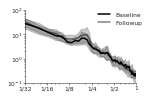

In [116]:
#data
psp_followup_avg = pd.read_hdf(join(edition, 'Figures', 'data', 'psp_followup_avg.hdf'), key='data')
psp_baseline_avg = pd.read_hdf(join(edition, 'Figures', 'data', 'psp_baseline_avg.hdf'), 
key = 'data') 
subjects = np.intersect1d(psp_followup_avg.index, psp_baseline_avg.index)

print(subjects)

baseline_color='black'
follow_color='grey'

f, ax = plt.subplots(figsize=(1/2*4, 2/3*2))
ci=95

stacked = psp_baseline_avg.loc[subjects].drop(['session'], axis=1).unstack().reset_index()
plot = sns.lineplot(data= stacked, x='level_0', y=0, ci=ci, color=baseline_color, lw=lw_power1, label='Baseline')

stacked = psp_followup_avg.loc[subjects].drop(['session'], axis=1).unstack().reset_index()
plot = sns.lineplot(data= stacked, x='level_0', y=0, ci=ci, color=baseline_color, alpha=.5, lw=lw_power1, label='Followup')

plot.set(xscale='log', yscale='log')
plot.set(xlim = (1/32, 1), ylim=(.1, 100))
ax.set(xlabel='',
      ylabel='',
      xticks=[1/32,1/16, 1/8, 1/4, 1/2, 1],
      xticklabels=['1/32','1/16', '1/8', '1/4', '1/2', '1'])
sns.despine()

# plt.plot(auc_x, func_powerlaw(auc_x, *popt), color='black', linestyle='--', lw=lw_power)
# plt.plot(permut_x, ((pvals<.05)+1)*.02, color='black')

ax.legend(bbox_to_anchor=(1.1, 1.05), frameon=False)

#f.tight_layout()
f.savefig(join(out, 'PowerSpectra_FU.png'), dpi=600)






## 1F Metrics FU vs. BL

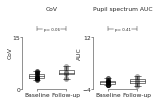

In [125]:
# Metrics FU vs. BL with FOOOV
## data
CoV = pd.read_hdf(join(edition, 'PowerFrequencies', 'CoV.hdf'), key='data')
CoV.loc[:, 'CoV'] = CoV.loc[:, 'std'] / CoV.loc[:, 'mean'] *100
CoV = CoV.loc[CoV.condition == 'bp_non_normalized'].groupby(['group', 'subject', 'session']).mean().reset_index()
auc = pd.read_hdf(join(edition, 'PowerFrequencies', 'auc_bp_non_normalized.hdf'), key='data')
psp_baseline_auc = auc.loc[(auc.group == 'PSP')&(auc.session == 'Baseline')]
psp_followup_auc = auc.loc[(auc.group == 'PSP')&(auc.session == 'Followup')]
fooov = pd.read_hdf(join(edition, 'SPECPARAMS', 'Specparams_2024-06-18.hdf'), key= 'data')
subjects = dt.follow

baseline_color='black'
follow_color='grey'
f, ax = plt.subplots(1, 2, figsize = (2/3*3.5, 2/3*2))
    

# 5. CoV
bl = CoV.loc[(CoV.group == 'PSP')&(CoV.session == 'Baseline')&CoV.subject.isin(subjects)].CoV.values
fl = CoV.loc[(CoV.group == 'PSP')&(CoV.session == 'Followup')&CoV.subject.isin(subjects)].CoV.values
subplot_2(j=0, yticks=[0, 15], ylabel = 'CoV', data = [bl, fl], xticklabels=['Baseline', 'Follow-up'], title = 'CoV')


# 6. AUC
bl = psp_baseline_auc.loc[psp_baseline_auc.subject.isin(subjects)].auc.values
fl=psp_followup_auc.loc[psp_followup_auc.subject.isin(subjects)].auc.values
subplot_2(j=1, yticks=[-4, 12], ylabel = 'AUC', data = [bl, fl], xticklabels=['Baseline', 'Follow-up'], title='Pupil spectrum AUC')


sns.despine(trim=True)
#f.tight_layout(pad=0, w_pad=0)
    
    
f.savefig(join(out, 'Pupil_metrics_followup_fooov_reduced.png'),  dpi=600)

## 4. PSP-RS vs. non-RS


## 1G Spectra

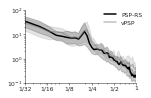

In [117]:
#data
# data for plotting: 
popt = np.load(join(edition, 'Figures', 'data', 'popt.npy')) 
auc_x = np.load(join(edition, 'Figures', 'data', 'auc_x.npy')) 
psp_baseline_avg = pd.read_hdf(join(edition, 'Figures', 'data', 'psp_baseline_avg.hdf'), 
                           key = 'data') 

f, ax = plt.subplots(figsize=(1/2*4, 2/3*2))

baseline_color='black'
follow_color='grey'

ci=95

stacked = psp_baseline_avg.loc[dt.RS].drop(['session'], axis=1).unstack().reset_index()
plot = sns.lineplot(data= stacked, x='level_0', y=0, ci=ci, color=baseline_color, lw=lw_power1, label='PSP-RS')

stacked = psp_baseline_avg.loc[dt.non_RS].drop(['session'], axis=1).unstack().reset_index()
plot = sns.lineplot(data= stacked, x='level_0', y=0, ci=ci, color=follow_color, alpha=.5, lw=lw_power1, label='vPSP')

plot.set(xscale='log', yscale='log')
plot.set(xlim = (1/32, 1), ylim=(.1, 100))
ax.set(xlabel='',
      ylabel='',
      xticks=[1/32,1/16, 1/8, 1/4, 1/2, 1],
      xticklabels=['1/32','1/16', '1/8', '1/4', '1/2', '1'])
sns.despine()

# plt.plot(auc_x, func_powerlaw(auc_x, *popt), color='black', linestyle='--', lw=lw_power)
# plt.plot(permut_x, ((pvals<.05)+1)*.02, color='black')

ax.legend(bbox_to_anchor=(1.1, 1.05), frameon=False)

#f.tight_layout()
f.savefig(join(out, 'PowerSpectra_RS.png'), dpi=600)



## 1H metrics

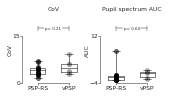

In [126]:
# Metrics FU vs. BL with FOOOV
CoV = pd.read_hdf(join(edition, 'PowerFrequencies', 'CoV.hdf'), key='data')
CoV.loc[:, 'CoV'] = CoV.loc[:, 'std'] / CoV.loc[:, 'mean'] *100
CoV = CoV.loc[CoV.condition == 'bp_non_normalized'].groupby(['group', 'subject', 'session']).mean().reset_index()
auc = pd.read_hdf(join(edition, 'PowerFrequencies', 'auc_bp_non_normalized.hdf'), key='data')
psp_baseline_auc = auc.loc[(auc.group == 'PSP')&(auc.session == 'Baseline')]

baseline_color='black'
follow_color='grey'

f, ax = plt.subplots(1, 2, figsize = (2/3*3.5, 2/3*2))

# 5. CoV
bl = CoV.loc[(CoV.group == 'PSP')&(CoV.session == 'Baseline')&(CoV.subject.isin(dt.RS))].CoV.values
fl = CoV.loc[(CoV.group == 'PSP')&(CoV.session == 'Baseline')&(CoV.subject.isin(dt.non_RS))].CoV.values
subplot_2(j=0, yticks=[0, 15], ylabel = 'CoV', data = [bl, fl], xticklabels=['PSP-RS', 'vPSP'], title='CoV')

# 6. AUC
bl = psp_baseline_auc.loc[psp_baseline_auc.subject.isin(dt.RS)].auc.values
fl=psp_baseline_auc.loc[psp_baseline_auc.subject.isin(dt.non_RS)].auc.values
subplot_2(j=1, yticks=[-4, 12], ylabel = 'AUC', data = [bl, fl], xticklabels=['PSP-RS', 'vPSP'], title='Pupil spectrum AUC')

sns.despine(trim=True)
f.tight_layout(pad=.5, w_pad=0)
    
f.savefig(join(out, 'Pupil_metrics_RS_fooov_reduced.png'),  dpi=600)

## 5. Modeling examples

## 1B Modeling examples
- example data generated at end of Specparams

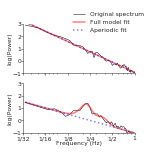

In [113]:
no_hippus = pd.read_hdf(join(edition, 'Figures', 'data', 'no_hippus_07.hdf'), key='data')
hippus = pd.read_hdf(join(edition, 'Figures', 'data', 'hippus_08.hdf'), key='data')

f, ax = plt.subplots(2, 1, figsize=(2, 2))


ax[0].plot(no_hippus.freqs.values, no_hippus.power_spectrum.values, color= 'black', lw=lw_power1-1, alpha=1, label = 'Original spectrum')
ax[0].plot(no_hippus.freqs.values, no_hippus.modeled_spectrum_.values, color= 'red', alpha=.5, lw=lw_power1, label = 'Full model fit')
ax[0].plot(no_hippus.freqs.values, no_hippus._ap_fit.values, color= 'blue', linestyle='dotted', alpha=.5, lw=lw_power1, label = 'Aperiodic fit')

ax[0].set(xscale='log')
ax[0].set(xlim = (1/32, 1), ylim=(-1, 3))
ax[0].set(xlabel='',
      ylabel='log(Power)',
      xticks=[1/32,1/16, 1/8, 1/4, 1/2, 1],
      xticklabels=[],
      yticks=[-1, 0, 1, 2, 3])

ax[1].plot(hippus.freqs.values, hippus.power_spectrum.values, color= 'black', lw=lw_power1-1, alpha=1,)
ax[1].plot(hippus.freqs.values, hippus.modeled_spectrum_.values, color= 'red', alpha=.5, lw=lw_power1)
ax[1].plot(hippus.freqs.values, hippus._ap_fit.values, color= 'blue', linestyle='dotted', alpha=.5, lw=lw_power1)

ax[1].set(xscale='log')
ax[1].set(xlim = (1/32, 1), ylim=(-1, 3))
ax[1].set(ylabel='log(Power)', xlabel = 'Frequency (Hz)',
      xticks=[1/32,1/16, 1/8, 1/4, 1/2, 1],
      xticklabels=['1/32','1/16', '1/8', '1/4', '1/2', '1'],
      yticks=[-1, 0, 1, 2, 3])




sns.despine()
f.legend(bbox_to_anchor=(1.04, 1.02), frameon=False)
#f.tight_layout()

f.savefig(join(out, 'Example_model_no_hippus.png'),  dpi=600)

## 1C
- new specparams, so slightly different

In [56]:
params = pd.read_hdf(join(edition, 'SPECPARAMS', 'Specparams_2025-09-09.hdf'), key= 'data')

### Exclude PD sub 12
params = params.set_index(['group', 'subject']).drop(('PD', '12')).reset_index()

In [57]:
print('PSP: {0} with at least 1 peak, {1} with no detected peak'.format(params.loc[(params.session == 'Baseline')&(~params.peak1_CF.isnull())].groupby('group').count().loc['PSP'].session,
                                                                       params.loc[(params.session == 'Baseline')&(params.peak1_CF.isnull())].groupby('group').count().loc['PSP'].session))

print('PD: {0} with at least 1 peak, {1} with no detected peak'.format(params.loc[(params.session == 'Baseline')&(~params.peak1_CF.isnull())].groupby('group').count().loc['PD'].session,
                                                                       params.loc[(params.session == 'Baseline')&(params.peak1_CF.isnull())].groupby('group').count().loc['PD'].session))

print('HC: {0} with at least 1 peak, {1} with no detected peak'.format(params.loc[(params.session == 'Baseline')&(~params.peak1_CF.isnull())].groupby('group').count().loc['Control'].session,
                                                                       params.loc[(params.session == 'Baseline')&(params.peak1_CF.isnull())].groupby('group').count().loc['Control'].session))


PSP: 12 with at least 1 peak, 8 with no detected peak
PD: 7 with at least 1 peak, 4 with no detected peak
HC: 6 with at least 1 peak, 6 with no detected peak


Hippus
No hippus


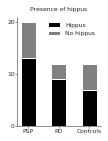

In [103]:
groups = (
    "PSP",
    "PD",
    "Controls",
)
weight_counts = {
    "Hippus": np.array([13,9,7]),
    "No hippus": np.array([7,3,5])
}

textures = {"Hippus": ['x', 'black'],
    "No hippus": ['', 'grey']}

width = 0.5

fig, ax = plt.subplots(figsize=(1.5, 2))
bottom = np.zeros(3)




for boolean, weight_count in weight_counts.items():
    print(boolean)
    p = ax.bar(groups, weight_count, width, label=boolean, bottom=bottom, color=textures[boolean][1])
    bottom += weight_count

ax.set_title("Presence of hippus")
ax.legend(loc="upper right", frameon=False)

ax.set(yticks=[0, 10, 20])

sns.despine()
fig.savefig(join(out, 'hippus_presence.png'),  dpi=600)

## 1I ROC plots


In [54]:
colors = {'Control':control_color,
         'PD':ips_color}

def roc_auc_by_group(
    df: pd.DataFrame,
    x_col: str = "x",
    group_col: str = "group",
    positive_label: str = "A",
    compare_against=("B", "C"),
    compute_optimal_threshold: bool = True,
    auto_orient_scores: bool = True,
    plot: bool = True,
    title: str = 'Parameter'
):
    """
    ROC + AUC for distinguishing `positive_label` vs each group in `compare_against`
    using the numeric score in `x_col`. The reported optimal threshold is ALWAYS on
    the ORIGINAL x-scale, with the correct inequality.

    Returns
    -------
    results: dict keyed by target group, each with:
        - auc
        - fpr, tpr, thresholds_on_score (the raw ROC outputs)
        - threshold_on_x (optimal cutoff on original x scale)
        - rule (string like "predict A if x >= T" or "predict A if x <= T")
        - sensitivity, specificity at that cutoff
        - orientation ('higher_x_is_A' True/False)
    """
    # basic checks
    if x_col not in df.columns or group_col not in df.columns:
        raise ValueError(f"DataFrame must contain '{x_col}' and '{group_col}'.")
    if positive_label not in set(df[group_col]):
        raise ValueError(f"Positive label '{positive_label}' not found in '{group_col}'.")

    use_groups = {positive_label, *compare_against}
    work = df[df[group_col].isin(use_groups)][[x_col, group_col]].dropna().copy()

    results = {}

    for neg in compare_against:
        sub = work[work[group_col].isin([positive_label, neg])].copy()
        if sub.empty:
            raise ValueError(f"No rows for comparison {positive_label} vs {neg}.")

        y_true = (sub[group_col] == positive_label).astype(int).to_numpy()
        x = sub[x_col].astype(float).to_numpy()

        # Start with original orientation (higher x -> predict A)
        sign = 1.0
        y_score = sign * x
        fpr, tpr, thr_used = roc_curve(y_true, y_score)
        auc_val = roc_auc_score(y_true, y_score)

        # If AUC < 0.5 and allowed, flip orientation for ROC computation
        if auto_orient_scores and auc_val < 0.5:
            sign = -1.0
            y_score = sign * x  # now y_score = -x
            fpr, tpr, thr_used = roc_curve(y_true, y_score)
            auc_val = roc_auc_score(y_true, y_score)

        entry = {
            "fpr": fpr,
            "tpr": tpr,
            "thresholds_on_score": thr_used,
            "auc": float(auc_val),
            "orientation": bool(sign > 0),  # True => higher x favors A
        }

        if compute_optimal_threshold:
            # Youden's J
            j = tpr - fpr

            # Ignore the first threshold (often inf) and any non-finite thresholds
            valid = np.isfinite(thr_used)
            if valid.sum() == 0:
                idx = int(np.argmax(j))  # fallback, but should rarely happen
            else:
                j_masked = np.where(valid, j, -np.inf)
                idx = int(np.argmax(j_masked))

            thr_score = float(thr_used[idx])  # threshold on the possibly flipped score

            # Convert the optimal threshold back to the ORIGINAL x scale
            # If sign == +1: predict A if x >= thr_score
            # If sign == -1: rule on score is (-x) >= thr_score  =>  x <= -thr_score
            if sign > 0:
                thr_x = thr_score
                rule = f"predict {positive_label} if {x_col} >= {thr_x:.6g}"
            else:
                thr_x = -thr_score
                rule = f"predict {positive_label} if {x_col} <= {thr_x:.6g}"

            sens = float(tpr[idx])
            spec = float(1 - fpr[idx])

            entry.update({
                "threshold_on_x": float(thr_x),
                "rule": rule,
                "sensitivity": sens,
                "specificity": spec,
                "youden_J": float(j[idx]),
            })

        results[neg] = entry        
    return results

In [55]:
auc = pd.read_hdf(join(edition, 'PowerFrequencies', 'auc_bp_non_normalized.hdf'), key='data')
cov = pd.read_hdf(join(edition, 'PowerFrequencies', 'CoV.hdf'), key='data')
cov = cov.loc[cov.condition == 'bp_non_normalized']
cov = cov.groupby(['group', 'session', 'subject']).mean().reset_index()
cov['cov']= cov.loc[:, 'std'] / cov.loc[:, 'mean']

cov = cov.loc[(cov.group.isin(['Control', 'PSP', 'PD']))&(cov.session == 'Baseline')]
auc = auc.loc[(auc.group.isin(['PSP', 'PD', 'Control']))&(auc.session == 'Baseline')]

### Exclude PD subject 12
cov = cov.set_index(['group', 'subject']).drop(('PD', '12')).reset_index()
auc = auc.set_index(['group', 'subject']).drop(('PD', '12')).reset_index()

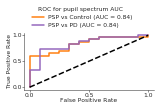

In [140]:
results = roc_auc_by_group(auc, x_col="auc", group_col="group", positive_label='PSP', compare_against=['Control', 'PD'], title='AUC')

f, ax = plt.subplots(figsize=(2.4, 2/3*2))
for neg in ['Control', 'PD']:
    tpr = results[neg]['tpr']
    fpr = results[neg]['fpr']
    auc_val = results[neg]['auc']

    ax.plot(fpr, tpr, label=f"PSP vs {neg} (AUC = {auc_val:.2f})", color=colors[neg])
ax.plot([0, 1], [0, 1], linestyle="--", color='black')
ax.set(xlabel = "False Positive Rate", ylabel="True Positive Rate", 
      xticks=[0, .5, 1],
      yticks=[0, .5, 1])
f.text(0.5, 1.08, "ROC for pupil spectrum AUC", ha="center", va="bottom", fontsize=6)

f.legend(bbox_to_anchor=(.8, 1.05), frameon=False)
sns.despine()
f.tight_layout()
f.savefig(join(out, 'ROC_AUC.png'),  dpi=600, bbox_inches="tight")


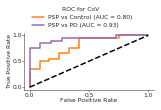

In [139]:
results = roc_auc_by_group(cov, x_col="cov", group_col="group", positive_label='PSP', compare_against=['Control', 'PD'], title='CoV')

f, ax = plt.subplots(figsize=(2.4, 2/3*2))
for neg in ['Control', 'PD']:
    tpr = results[neg]['tpr']
    fpr = results[neg]['fpr']
    auc_val = results[neg]['auc']

    ax.plot(fpr, tpr, label=f"PSP vs {neg} (AUC = {auc_val:.2f})", color=colors[neg])
ax.plot([0, 1], [0, 1], linestyle="--", color='black')
ax.set(xlabel = "False Positive Rate", ylabel="True Positive Rate", 
      xticks=[0, .5, 1],
      yticks=[0, .5, 1])
#ax.set_title('ROC for CoV')

f.legend(bbox_to_anchor=(.8, 1.05), frameon=False)
f.text(0.5, 1.08, "ROC for CoV", ha="center", va="bottom", fontsize=6)
sns.despine()
f.tight_layout()
f.savefig(join(out, 'ROC_CoV.png'),  dpi=600, bbox_inches="tight")


In [47]:
results

{'Control': {'fpr': array([0.        , 0.        , 0.        , 0.16666667, 0.16666667,
         0.25      , 0.25      , 0.33333333, 0.33333333, 0.41666667,
         0.41666667, 0.5       , 0.5       , 0.58333333, 0.58333333,
         1.        , 1.        ]),
  'tpr': array([0.  , 0.05, 0.65, 0.65, 0.7 , 0.7 , 0.75, 0.75, 0.8 , 0.8 , 0.85,
         0.85, 0.9 , 0.9 , 0.95, 0.95, 1.  ]),
  'thresholds_on_score': array([ 4.08805381,  3.08805381,  1.76452492,  1.50708607,  1.47390741,
          1.39430042,  1.21724466,  1.19765365,  0.73520624,  0.48586221,
          0.46602836,  0.25327536,  0.19476247, -0.04683754, -0.3164877 ,
         -6.35559214, -6.7621386 ]),
  'auc': 0.8374999999999999,
  'orientation': False,
  'threshold_on_x': -1.7645249185871759,
  'rule': 'predict PSP if auc <= -1.76452',
  'sensitivity': 0.65,
  'specificity': 1.0,
  'youden_J': 0.65},
 'PD': {'fpr': array([0.        , 0.        , 0.        , 0.09090909, 0.09090909,
         0.36363636, 0.36363636, 0.54545455

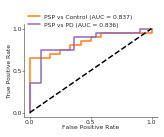